In [38]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import json

PROJECT_DIR   = "/content/drive/MyDrive/DLP2"
PROCESSED_DIR = os.path.join(PROJECT_DIR, "data/processed")
MODELS_DIR    = os.path.join(PROJECT_DIR, "models")
RESULTS_DIR   = os.path.join(PROJECT_DIR, "results")
FIGURES_DIR   = os.path.join(PROJECT_DIR, "figures")

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

X_train = np.load(os.path.join(PROCESSED_DIR, "X_train.npy"))
X_val   = np.load(os.path.join(PROCESSED_DIR, "X_val.npy"))
X_test  = np.load(os.path.join(PROCESSED_DIR, "X_test.npy"))
y_train = np.load(os.path.join(PROCESSED_DIR, "y_train.npy"))
y_val   = np.load(os.path.join(PROCESSED_DIR, "y_val.npy"))
y_test  = np.load(os.path.join(PROCESSED_DIR, "y_test.npy"))

with open(os.path.join(PROCESSED_DIR, "activity_labels.json"), "r") as f:
    activity_labels = json.load(f)

print("X_train:", X_train.shape)
print("X_val:",   X_val.shape)
print("X_test:",  X_test.shape)
print(activity_labels)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
X_train: (5881, 128, 9)
X_val: (1471, 128, 9)
X_test: (2947, 128, 9)
{'0': 'WALKING', '1': 'WALKING_UPSTAIRS', '2': 'WALKING_DOWNSTAIRS', '3': 'SITTING', '4': 'STANDING', '5': 'LAYING'}


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix

TIME_STEPS   = X_train.shape[1]   # 128
NUM_CHANNELS = X_train.shape[2]   # 9
NUM_CLASSES  = len(activity_labels)
INPUT_SHAPE  = (TIME_STEPS, NUM_CHANNELS)

print("Input shape:", INPUT_SHAPE)
print("Number of classes:", NUM_CLASSES)
print("GPU:", tf.config.list_physical_devices('GPU'))

Input shape: (128, 9)
Number of classes: 6
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [40]:
ae_input = layers.Input(shape=INPUT_SHAPE)

# Encoder
enc = layers.Conv1D(64, 3, activation='relu', padding='same')(ae_input)
enc = layers.MaxPooling1D(2)(enc)
enc = layers.Conv1D(128, 3, activation='relu', padding='same')(enc)
encoded = layers.MaxPooling1D(2)(enc)   # (None, 32, 128)

# Decoder
dec = layers.Conv1D(128, 3, activation='relu', padding='same')(encoded)
dec = layers.UpSampling1D(2)(dec)
dec = layers.Conv1D(64, 3, activation='relu', padding='same')(dec)
dec = layers.UpSampling1D(2)(dec)
decoded = layers.Conv1D(NUM_CHANNELS, 3, activation='linear', padding='same')(dec)

autoencoder = keras.Model(ae_input, decoded, name="autoencoder")
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

ae_history = autoencoder.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=30,
    batch_size=64,
    callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=1
)

# Encoder ayır ve dondur
encoder = keras.Model(ae_input, encoded, name="encoder")
for layer in encoder.layers:
    layer.trainable = False

print("Encoder output shape:", encoder.output_shape)

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_14 (Conv1D)              │ (None, 128, 64)        │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_15 (Conv1D)              │ (None, 64, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_16 (Conv1D)              │ (None, 32, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_4 (UpSampling1D)  │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_17 (Conv1D)              │ (None, 64, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_5 (UpSampling1D)  │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_18 (Conv1D)              │ (None, 128, 9)         │         1,737 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,153 (399.04 KB)

 Trainable params: 102,153 (399.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.2041 - val_loss: 0.0821
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0686 - val_loss: 0.0584
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0547 - val_loss: 0.0479
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0453 - val_loss: 0.0457
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0399 - val_loss: 0.0384
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0373 - val_loss: 0.0355
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0343 - val_loss: 0.0340
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0316 - val_loss: 0.0339
Epoch 9/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0312 - val_loss: 0.0292
Epoch 10/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0283 - val_loss: 0.0278
Epoch 11/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0291 - val_loss: 0.0266
Epoch 12/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0261 - val_l

In [41]:
def build_exp5_model(dropout_rate=0.3, gru_units=64, learning_rate=1e-3):
    """
    Exp 5: Encoder(frozen) → Conv1D → BatchNorm → GRU → Dropout → Dense
    Exp 4'ten farkı: BatchNorm + Dropout eklendi
    """
    enc_out = encoder.output   # (None, 32, 128)

    x = layers.Conv1D(64, 3, activation='relu', padding='same')(enc_out)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)

    x = layers.GRU(gru_units, return_sequences=False)(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(dropout_rate / 2)(x)
    output = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(encoder.input, output, name="Exp5_Regularized")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Denenecek konfigürasyonlar
configs = [
    {"dropout_rate": 0.2, "gru_units": 64,  "learning_rate": 1e-3, "batch_size": 64},
    {"dropout_rate": 0.3, "gru_units": 64,  "learning_rate": 1e-3, "batch_size": 64},
    {"dropout_rate": 0.3, "gru_units": 128, "learning_rate": 5e-4, "batch_size": 32},
    {"dropout_rate": 0.4, "gru_units": 128, "learning_rate": 1e-3, "batch_size": 64},
]

tuning_results = []

for i, cfg in enumerate(configs):
    print(f"\n--- Config {i+1}/{len(configs)}: {cfg} ---")
    m = build_exp5_model(
        dropout_rate=cfg["dropout_rate"],
        gru_units=cfg["gru_units"],
        learning_rate=cfg["learning_rate"]
    )
    hist = m.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=20,
        batch_size=cfg["batch_size"],
        callbacks=[keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True)],
        verbose=0
    )
    val_acc = max(hist.history['val_accuracy'])
    print(f"  → Best val_accuracy: {val_acc:.4f}")
    tuning_results.append({"config": cfg, "val_acc": val_acc})

# En iyi config
best = max(tuning_results, key=lambda x: x["val_acc"])
best_config = best["config"]
print("\n✅ Best config:", best_config)
print(f"✅ Best val_accuracy: {best['val_acc']:.4f}")


--- Config 1/4: {'dropout_rate': 0.2, 'gru_units': 64, 'learning_rate': 0.001, 'batch_size': 64} ---
  → Best val_accuracy: 0.9674

--- Config 2/4: {'dropout_rate': 0.3, 'gru_units': 64, 'learning_rate': 0.001, 'batch_size': 64} ---
  → Best val_accuracy: 0.9517

--- Config 3/4: {'dropout_rate': 0.3, 'gru_units': 128, 'learning_rate': 0.0005, 'batch_size': 32} ---
  → Best val_accuracy: 0.9633

--- Config 4/4: {'dropout_rate': 0.4, 'gru_units': 128, 'learning_rate': 0.001, 'batch_size': 64} ---
  → Best val_accuracy: 0.9579

✅ Best config: {'dropout_rate': 0.2, 'gru_units': 64, 'learning_rate': 0.001, 'batch_size': 64}
✅ Best val_accuracy: 0.9674


Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8288 - loss: 0.4787 - val_accuracy: 0.5996 - val_loss: 0.9331 - learning_rate: 0.0010
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9449 - loss: 0.1500 - val_accuracy: 0.8824 - val_loss: 0.3364 - learning_rate: 0.0010
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9437 - loss: 0.1364 - val_accuracy: 0.9443 - val_loss: 0.1572 - learning_rate: 0.0010
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9461 - loss: 0.1269 - val_accuracy: 0.9606 - val_loss: 0.1000 - learning_rate: 0.0010
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9495 - loss: 0.1253 - val_accuracy: 0.9388 - val_loss: 0.1707 - learning_rate: 0.0010
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9539 - loss: 0.1062 - val_accuracy: 0.9613 - val_loss: 0.0922 - learning_rate: 0.0010
Epoch 7/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9476 - loss: 0.1126 - val_acc

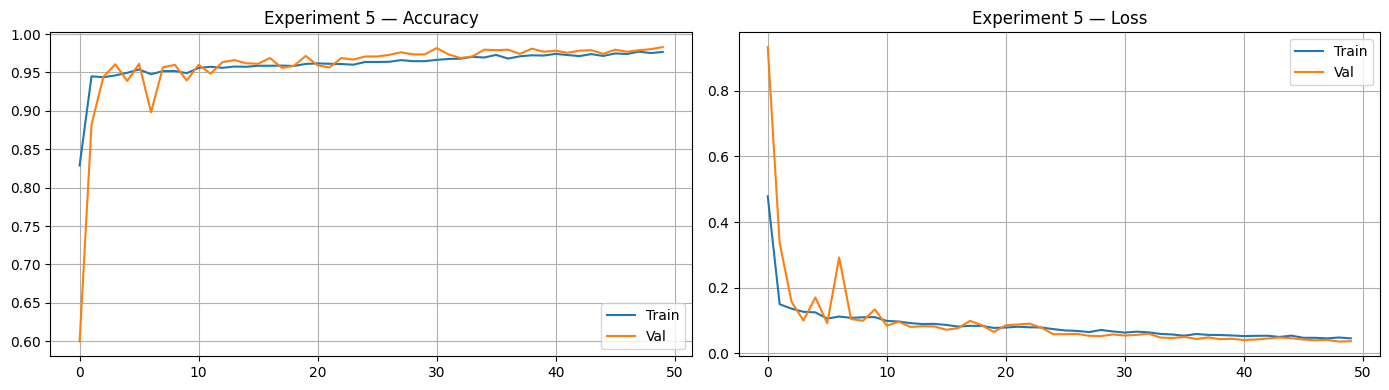

In [42]:
final_model = build_exp5_model(
    dropout_rate=best_config["dropout_rate"],
    gru_units=best_config["gru_units"],
    learning_rate=best_config["learning_rate"]
)

callbacks_exp5 = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=8, restore_best_weights=True
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(MODELS_DIR, "exp5_best.keras"),
        monitor='val_loss', save_best_only=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=4, verbose=1
    )
]

history_exp5 = final_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=best_config["batch_size"],
    callbacks=callbacks_exp5,
    verbose=1
)

# Training curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(history_exp5.history['accuracy'], label='Train')
ax1.plot(history_exp5.history['val_accuracy'], label='Val')
ax1.set_title('Experiment 5 — Accuracy')
ax1.legend(); ax1.grid(True)

ax2.plot(history_exp5.history['loss'], label='Train')
ax2.plot(history_exp5.history['val_loss'], label='Val')
ax2.set_title('Experiment 5 — Loss')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "exp5_training_curves.png"), dpi=300, bbox_inches="tight")
plt.show()

Test Accuracy: 0.9223
Test Loss:     0.3446
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
                    precision    recall  f1-score   support

           WALKING     0.9743    0.9940    0.9840       496
  WALKING_UPSTAIRS     0.9740    0.9533    0.9635       471
WALKING_DOWNSTAIRS     0.9415    0.9571    0.9492       420
           SITTING     0.8139    0.8106    0.8122       491
          STANDING     0.8410    0.8252    0.8330       532
            LAYING     0.9908    1.0000    0.9954       537

          accuracy                         0.9223      2947
         macro avg     0.9226    0.9234    0.9229      2947
      weighted avg     0.9218    0.9223    0.9220      2947



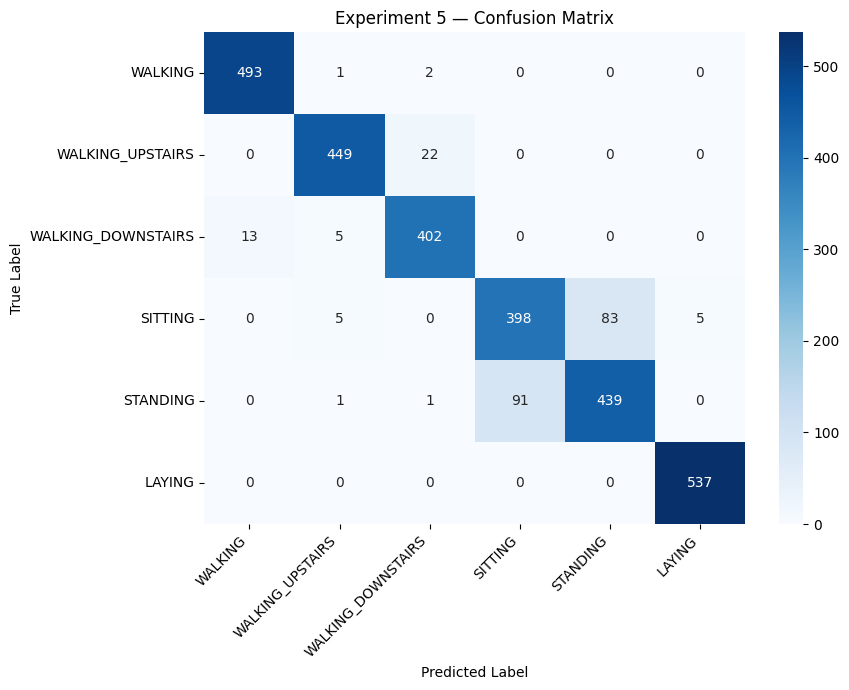

{'experiment': 'Experiment 5 - Final Regularized Model', 'model': 'Encoder(frozen) + Conv1D + BatchNorm + GRU + Dropout + Dense', 'input_shape': [128, 9], 'num_classes': 6, 'best_config': {'dropout_rate': 0.2, 'gru_units': 64, 'learning_rate': 0.001, 'batch_size': 64}, 'epochs_trained': 50, 'test_loss': 0.344587117433548, 'test_accuracy': 0.9222938418388367, 'total_parameters': 118406}


In [43]:
test_loss5, test_acc5 = final_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc5:.4f}")
print(f"Test Loss:     {test_loss5:.4f}")

y_pred5 = np.argmax(final_model.predict(X_test), axis=1)
target_names = [activity_labels[str(i)] for i in range(NUM_CLASSES)]

report5 = classification_report(y_test, y_pred5, target_names=target_names, digits=4)
print(report5)

with open(os.path.join(RESULTS_DIR, "exp5_classification_report.txt"), "w") as f:
    f.write(report5)

# Confusion matrix
cm5 = confusion_matrix(y_test, y_pred5)
plt.figure(figsize=(9, 7))
sns.heatmap(cm5, annot=True, fmt="d", xticklabels=target_names,
            yticklabels=target_names, cmap="Blues")
plt.title('Experiment 5 — Confusion Matrix')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "exp5_confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()

# Model kaydet
final_model.save(os.path.join(MODELS_DIR, "exp5_final.keras"))

# JSON kaydet
results5 = {
    "experiment": "Experiment 5 - Final Regularized Model",
    "model": "Encoder(frozen) + Conv1D + BatchNorm + GRU + Dropout + Dense",
    "input_shape": list(INPUT_SHAPE),
    "num_classes": NUM_CLASSES,
    "best_config": best_config,
    "epochs_trained": len(history_exp5.history["loss"]),
    "test_loss": float(test_loss5),
    "test_accuracy": float(test_acc5),
    "total_parameters": final_model.count_params()
}
with open(os.path.join(RESULTS_DIR, "exp5_results.json"), "w") as f:
    json.dump(results5, f, indent=4)

print(results5)